In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Define data directory
data_dir = Path('slice_0')

# Load all CSV files
action_df = pd.read_csv(data_dir / 'action.csv')
allocation_df = pd.read_csv(data_dir / 'allocation.csv')
energy_df = pd.read_csv(data_dir / 'energy.csv', header=None, names=['energy'])
latency_df = pd.read_csv(data_dir / 'latency.csv', header=None, names=['latency'])
rejection_df = pd.read_csv(data_dir / 'rejection.csv')
reward_df = pd.read_csv(data_dir / 'reward.csv', header=None, names=['reward'])
accumulated_df = pd.read_csv(data_dir / 'accumulated.csv')

print("Data loaded successfully!")
print(f"Number of episodes: {len(reward_df)}")
print(f"Action columns: {list(action_df.columns)}")
print(f"Allocation columns: {list(allocation_df.columns)}")
print(f"Rejection columns: {list(rejection_df.columns)}")

Data loaded successfully!
Number of episodes: 4106
Action columns: ['mec_0', 'mec_1', 'mec_2', 'mec_3', 'mec_4', 'link_0', 'link_1', 'link_2', 'link_3', 'link_4', 'link_5', 'link_6', 'link_7', 'link_8', 'link_9']
Allocation columns: ['mec_0', 'mec_1', 'mec_2', 'mec_3', 'mec_4', 'link_0', 'link_1', 'link_2', 'link_3', 'link_4', 'link_5', 'link_6', 'link_7', 'link_8', 'link_9']
Rejection columns: ['mec_0', 'mec_1', 'mec_2', 'mec_3', 'mec_4', 'link_0', 'link_1', 'link_2', 'link_3', 'link_4', 'link_5', 'link_6', 'link_7', 'link_8', 'link_9']


In [3]:
reward_df = reward_df[1:].reset_index(drop=True)
latency_df = latency_df[1:].reset_index(drop=True)
energy_df = energy_df[1:].reset_index(drop=True)

In [4]:
reward_df = reward_df.astype(float)
latency_df = latency_df.astype(float)
energy_df = energy_df.astype(float)

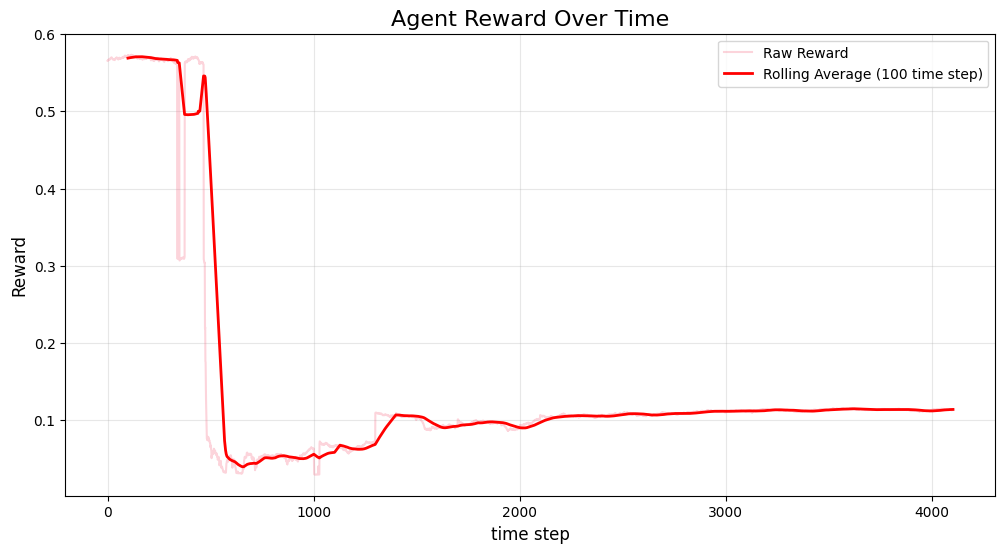

Mean reward: 0.1477
Std reward: 0.1484
Min reward: 0.0293
Max reward: 0.5733
Rolling average (last 100): 0.1139


In [5]:
# Cell 2: Plot reward over time
plt.figure(figsize=(12, 6))
plt.plot(reward_df.index, reward_df['reward'], alpha=0.3, label='Raw Reward')
reward_rolling = reward_df['reward'].rolling(window=100).mean()
plt.plot(reward_df.index, reward_rolling, linewidth=2, label='Rolling Average (100 time step)', color='red')
plt.title('Agent Reward Over Time', fontsize=16)
plt.xlabel('time step', fontsize=12)
plt.ylabel('Reward', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate and display reward statistics
print(f"Mean reward: {reward_df['reward'].mean():.4f}")
print(f"Std reward: {reward_df['reward'].std():.4f}")
print(f"Min reward: {reward_df['reward'].min():.4f}")
print(f"Max reward: {reward_df['reward'].max():.4f}")
print(f"Rolling average (last 100): {reward_rolling.iloc[-1]:.4f}")

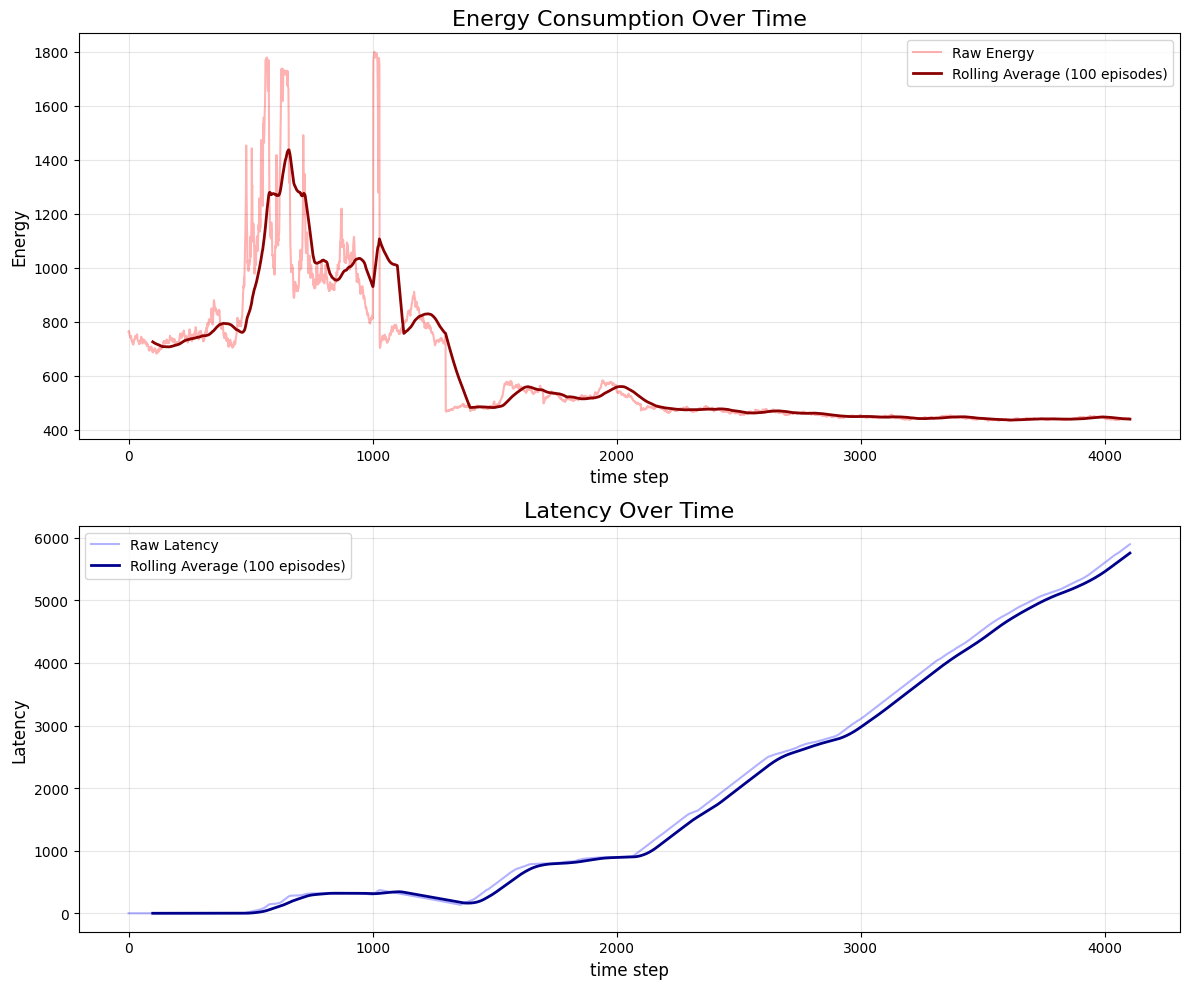

Energy Statistics:
Mean: 613.62, Std: 254.80
Min: 433.28, Max: 1800.60
Rolling average (last 1000): 439.44

Latency Statistics:
Mean: 1888.21, Std: 1857.51
Min: 1.00, Max: 5896.00
Rolling average (last 1000): 5755.81


In [6]:
# Cell 3: Plot energy and latency over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Energy plot
ax1.plot(energy_df.index, energy_df['energy'], alpha=0.3, color='red', label='Raw Energy')
energy_rolling = energy_df['energy'].rolling(window=100).mean()
ax1.plot(energy_df.index, energy_rolling, linewidth=2, label='Rolling Average (100 episodes)', color='darkred')
ax1.set_title('Energy Consumption Over Time', fontsize=16)
ax1.set_xlabel('time step', fontsize=12)
ax1.set_ylabel('Energy', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Latency plot
ax2.plot(latency_df.index, latency_df['latency'], alpha=0.3, color='blue', label='Raw Latency')
latency_rolling = latency_df['latency'].rolling(window=100).mean()
ax2.plot(latency_df.index, latency_rolling, linewidth=2, label='Rolling Average (100 episodes)', color='darkblue')
ax2.set_title('Latency Over Time', fontsize=16)
ax2.set_xlabel('time step', fontsize=12)
ax2.set_ylabel('Latency', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("Energy Statistics:")
print(f"Mean: {energy_df['energy'].mean():.2f}, Std: {energy_df['energy'].std():.2f}")
print(f"Min: {energy_df['energy'].min():.2f}, Max: {energy_df['energy'].max():.2f}")
print(f"Rolling average (last 1000): {energy_rolling.iloc[-1]:.2f}")

print("\nLatency Statistics:")
print(f"Mean: {latency_df['latency'].mean():.2f}, Std: {latency_df['latency'].std():.2f}")
print(f"Min: {latency_df['latency'].min():.2f}, Max: {latency_df['latency'].max():.2f}")
print(f"Rolling average (last 1000): {latency_rolling.iloc[-1]:.2f}")

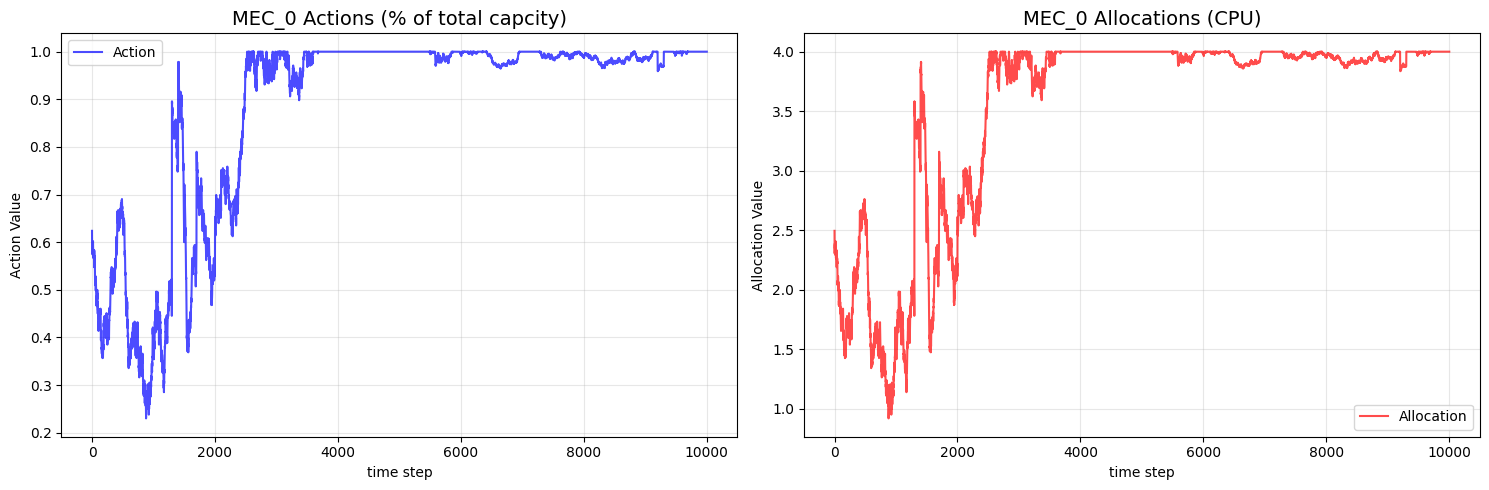

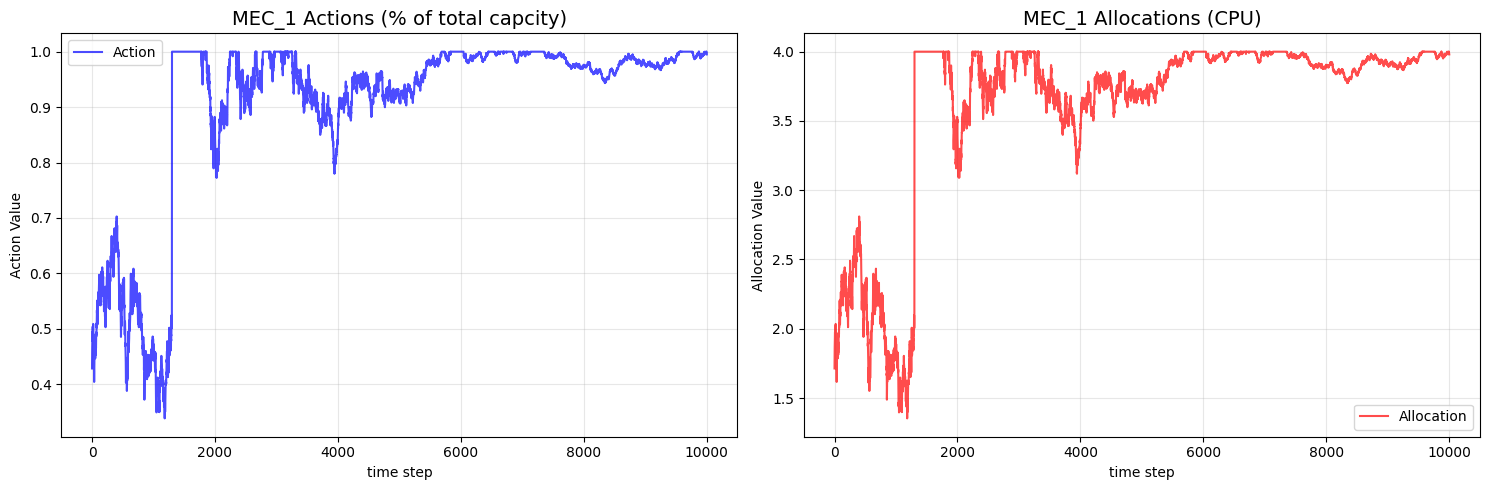

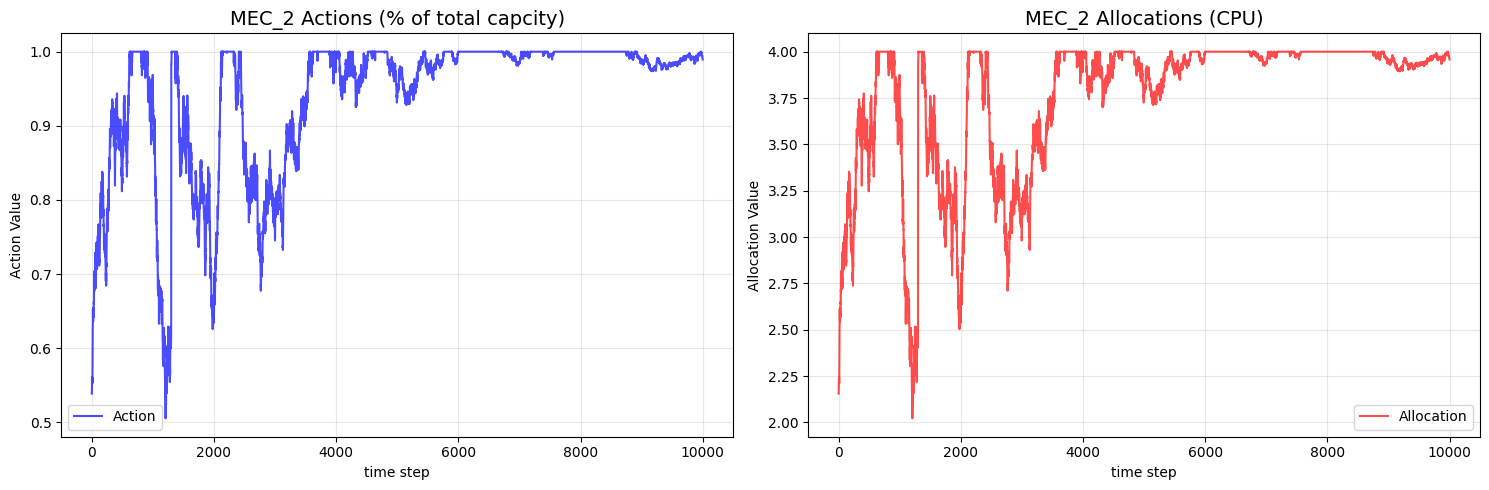

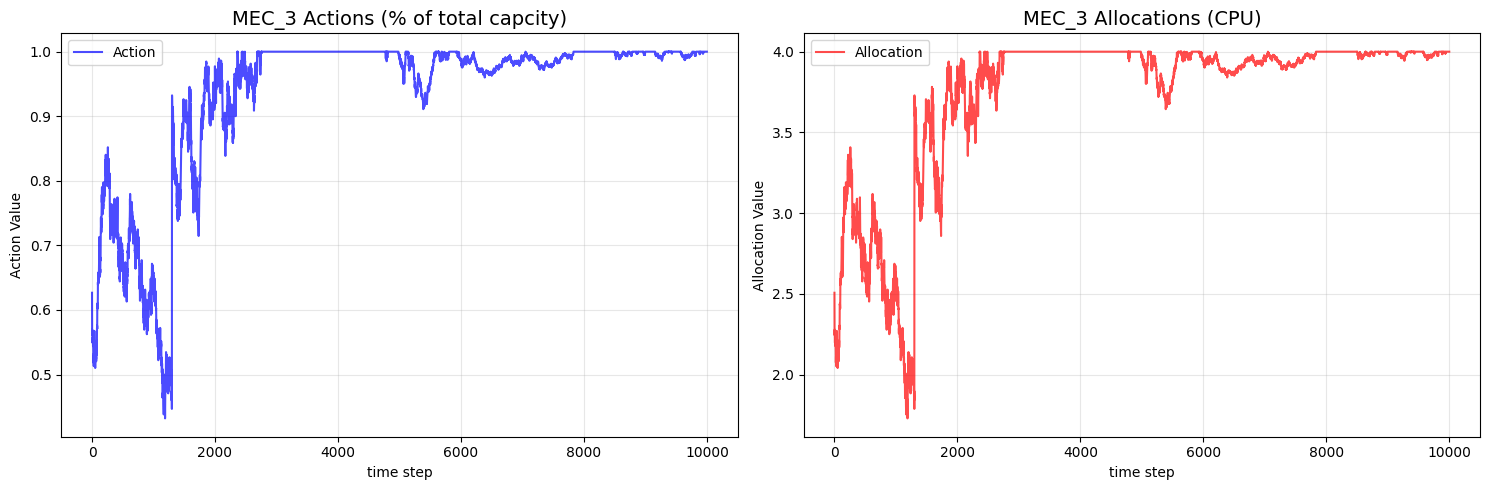

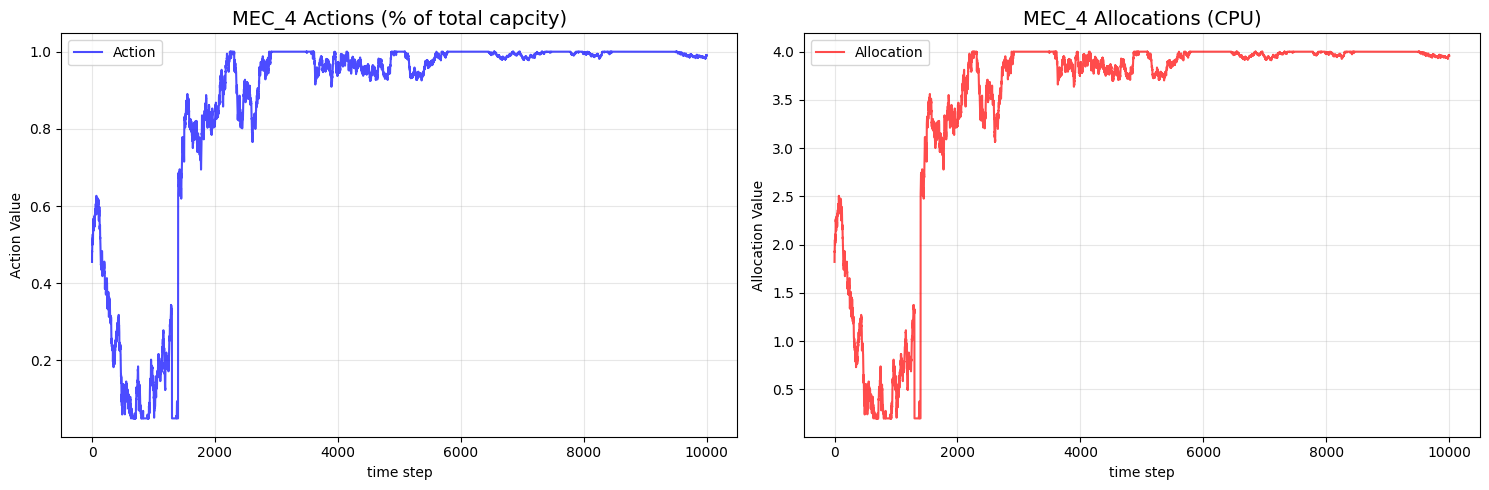

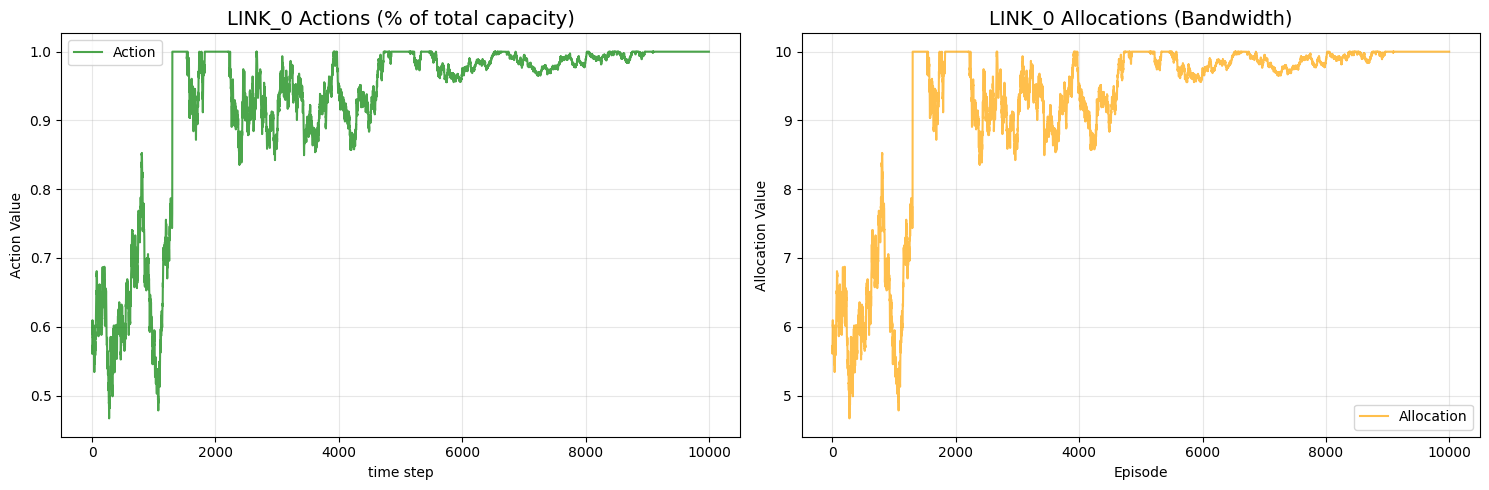

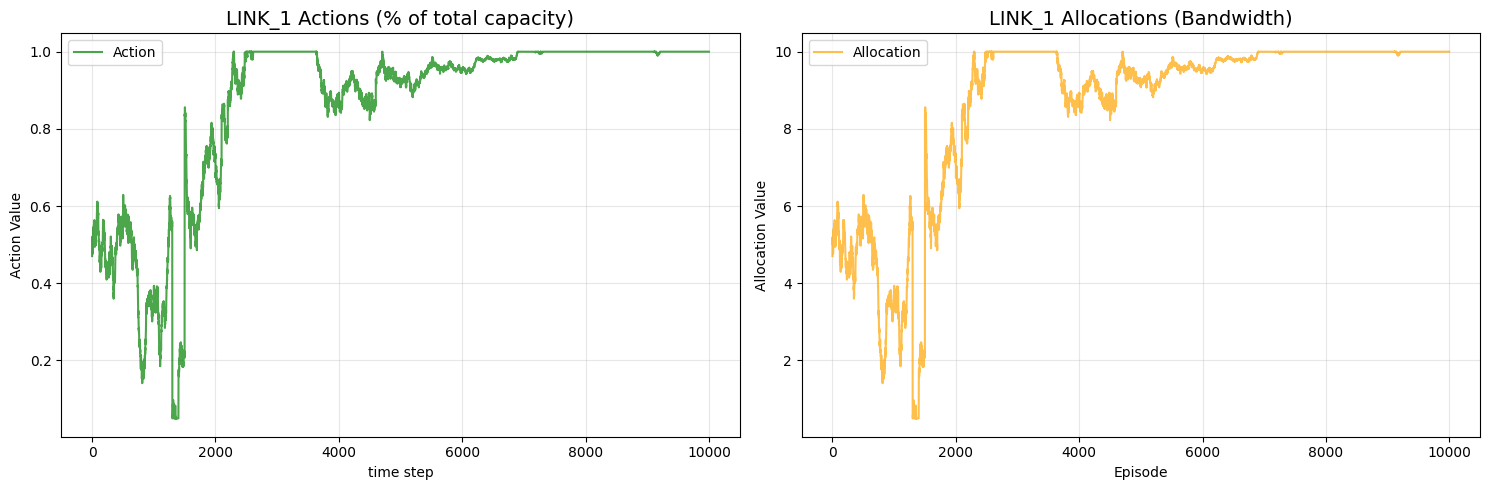

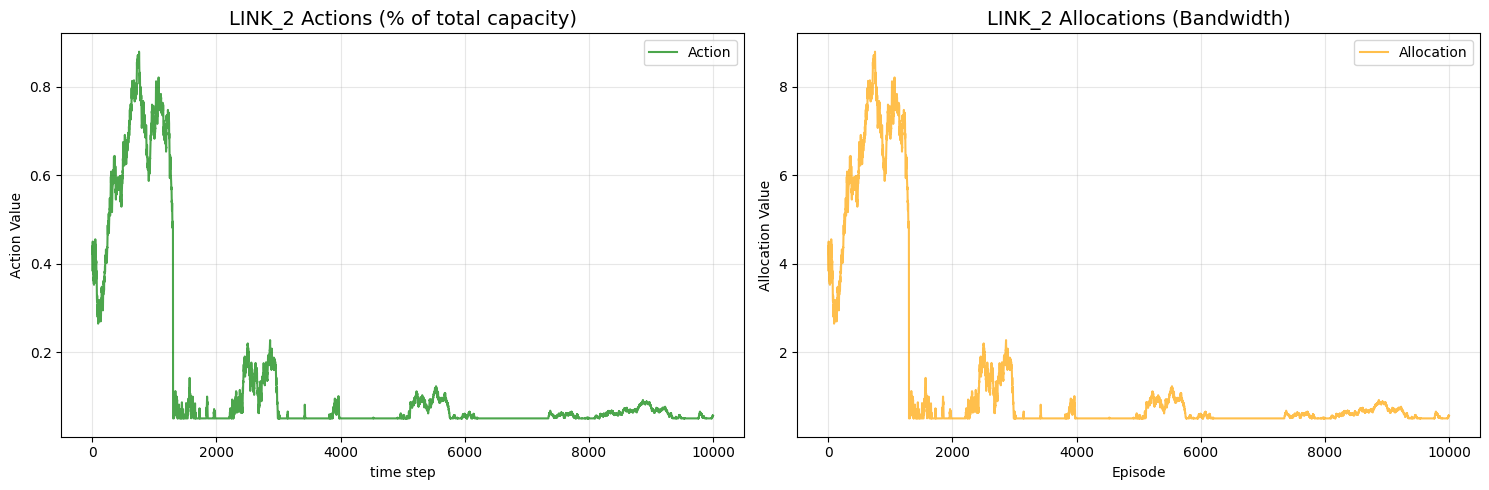

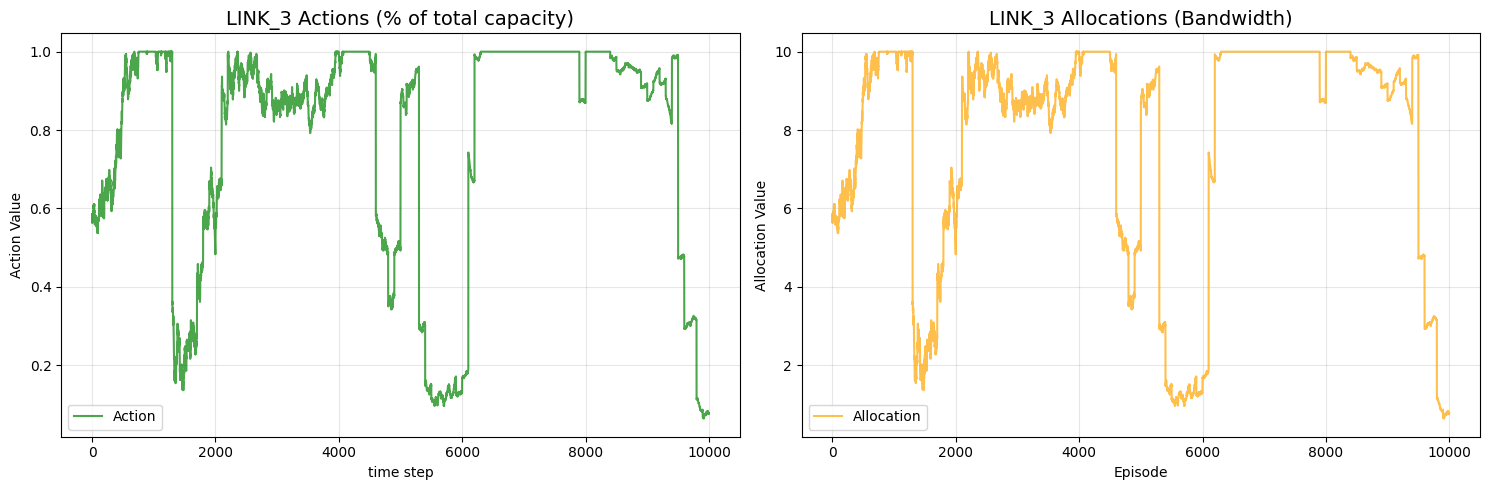

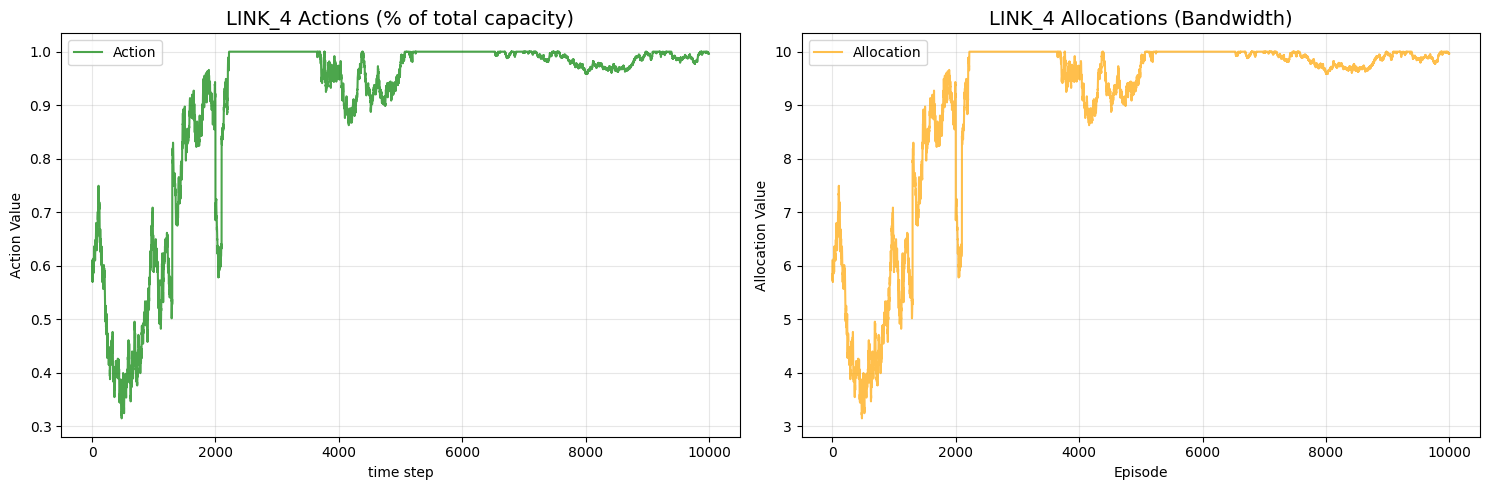

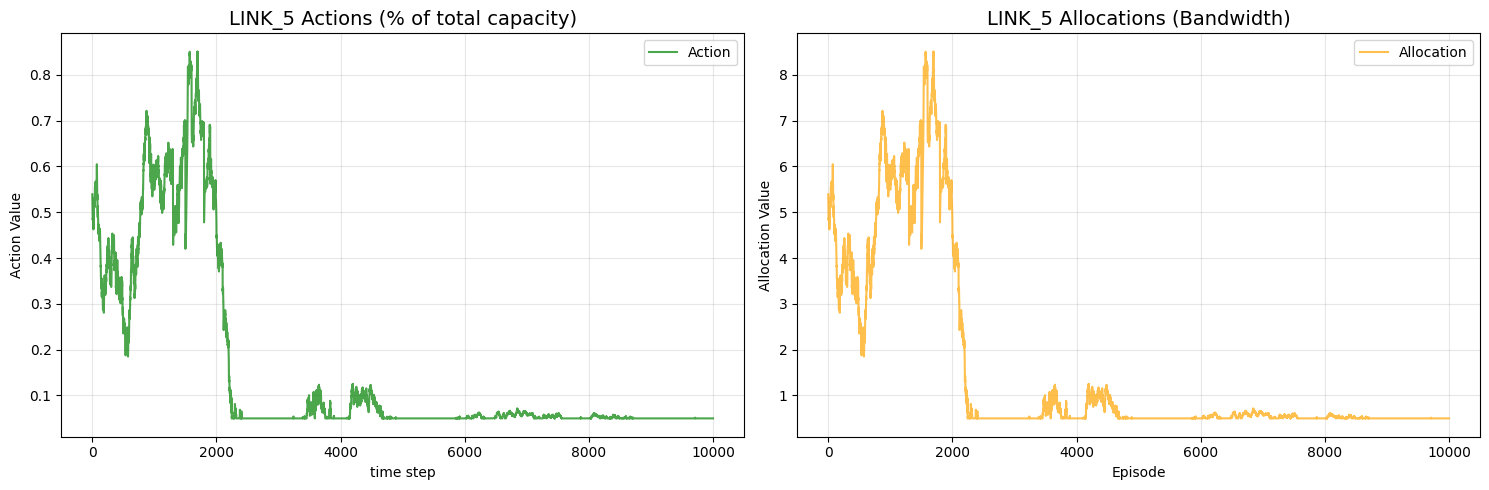

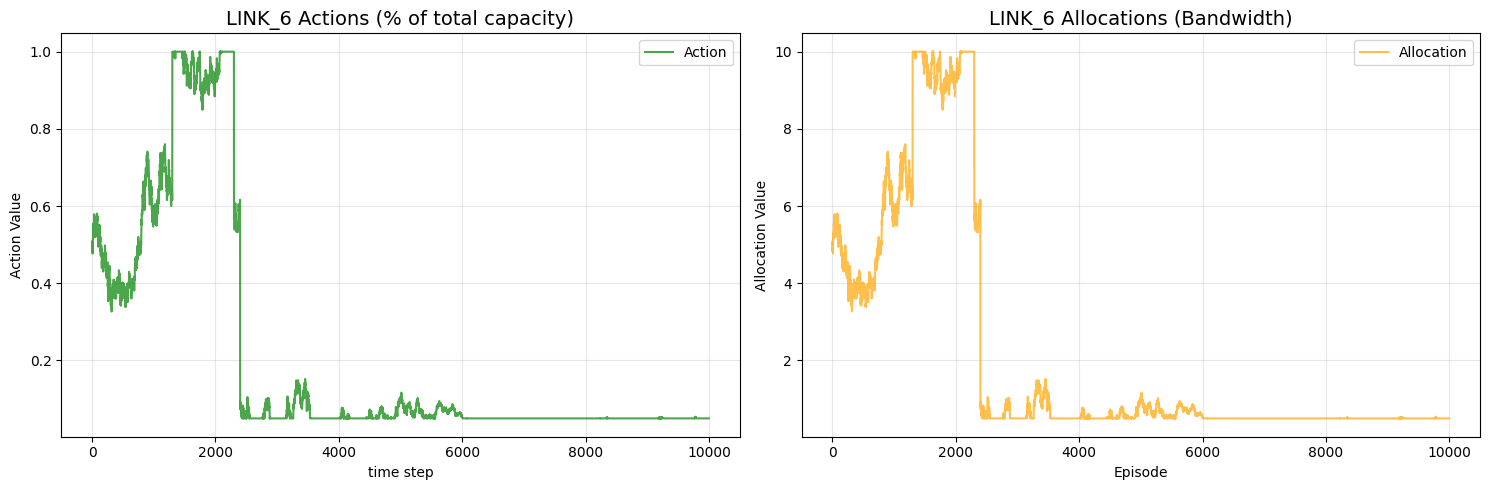

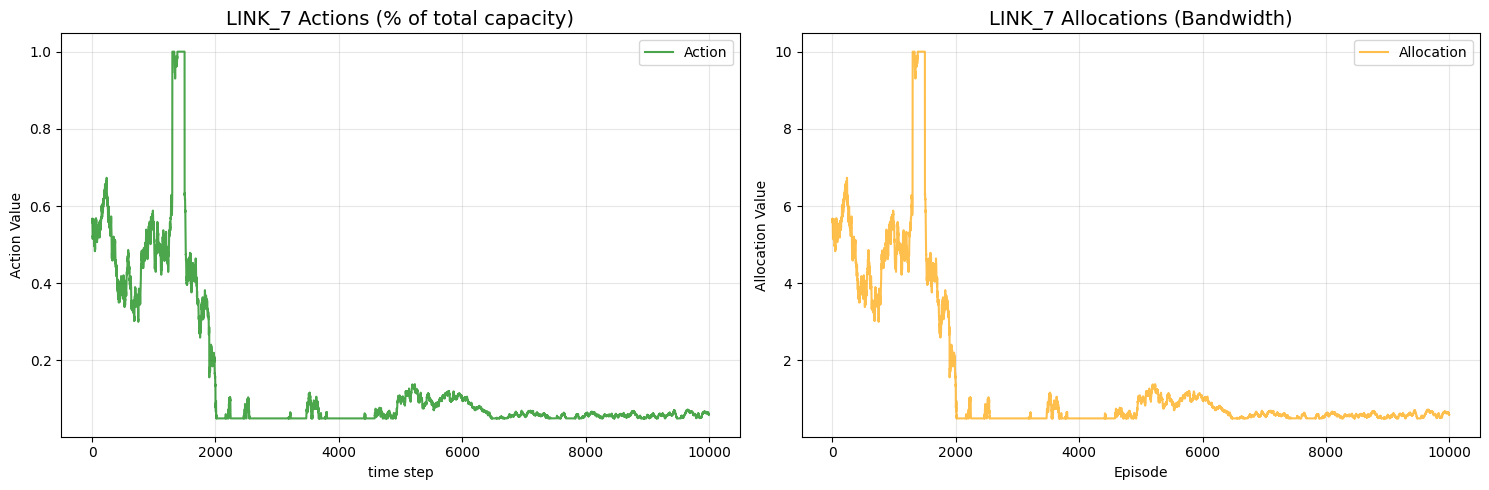

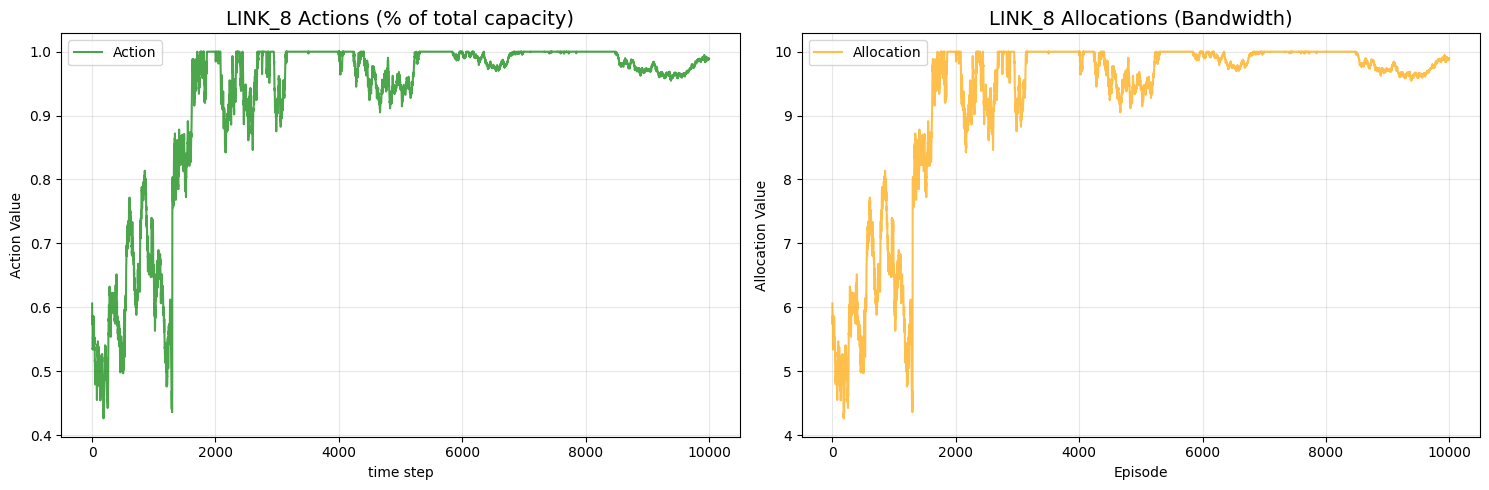

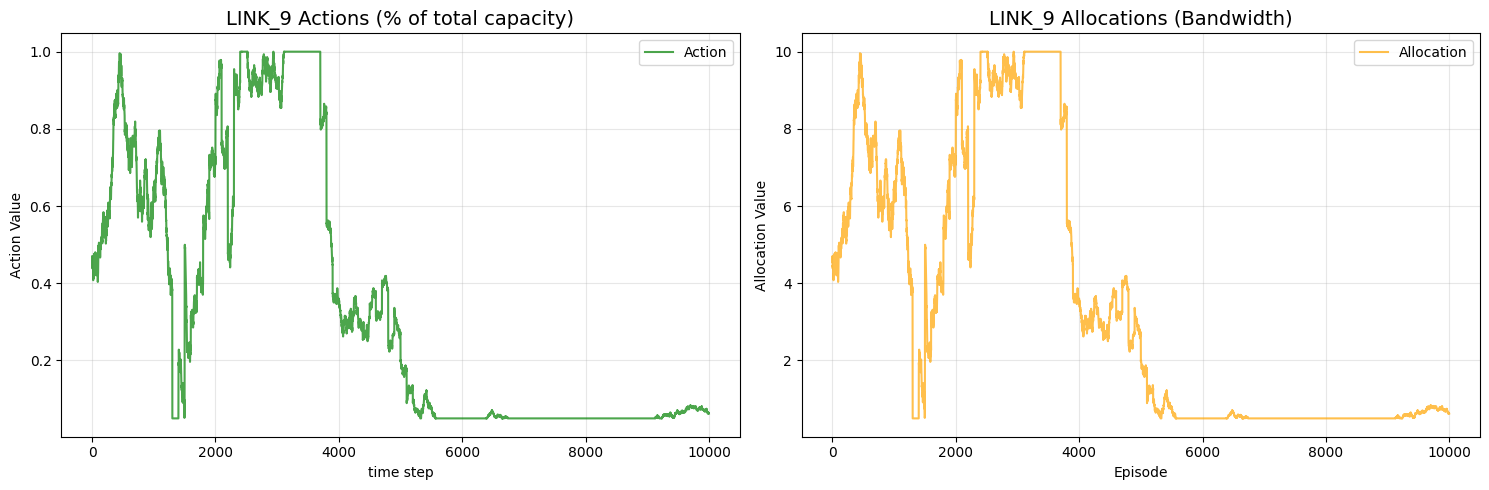

In [7]:
# Cell 4: Individual plots for each MEC and Link resource
sample_size = min(500000, len(action_df))  # Show more episodes for better trend visibility

# Plot MEC resources
mec_cols = [col for col in action_df.columns if col.startswith('mec_')]
for i, mec in enumerate(mec_cols):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Actions
    ax1.plot(action_df.index[:sample_size], action_df[mec][:sample_size], alpha=0.7, color='blue', label='Action')
    ax1.set_title(f'{mec.upper()} Actions (% of total capcity)', fontsize=14)
    ax1.set_xlabel('time step')
    ax1.set_ylabel('Action Value')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Allocations
    ax2.plot(allocation_df.index[:sample_size], allocation_df[mec][:sample_size], alpha=0.7, color='red', label='Allocation')
    ax2.set_title(f'{mec.upper()} Allocations (CPU)', fontsize=14)
    ax2.set_xlabel('time step')
    ax2.set_ylabel('Allocation Value')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Plot Link resources
link_cols = [col for col in action_df.columns if col.startswith('link_')]
for i, link in enumerate(link_cols):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Actions
    ax1.plot(action_df.index[:sample_size], action_df[link][:sample_size], alpha=0.7, color='green', label='Action')
    ax1.set_title(f'{link.upper()} Actions (% of total capacity)', fontsize=14)
    ax1.set_xlabel('time step')
    ax1.set_ylabel('Action Value')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Allocations
    ax2.plot(allocation_df.index[:sample_size], allocation_df[link][:sample_size], alpha=0.7, color='orange', label='Allocation')
    ax2.set_title(f'{link.upper()} Allocations (Bandwidth)', fontsize=14)
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Allocation Value')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    

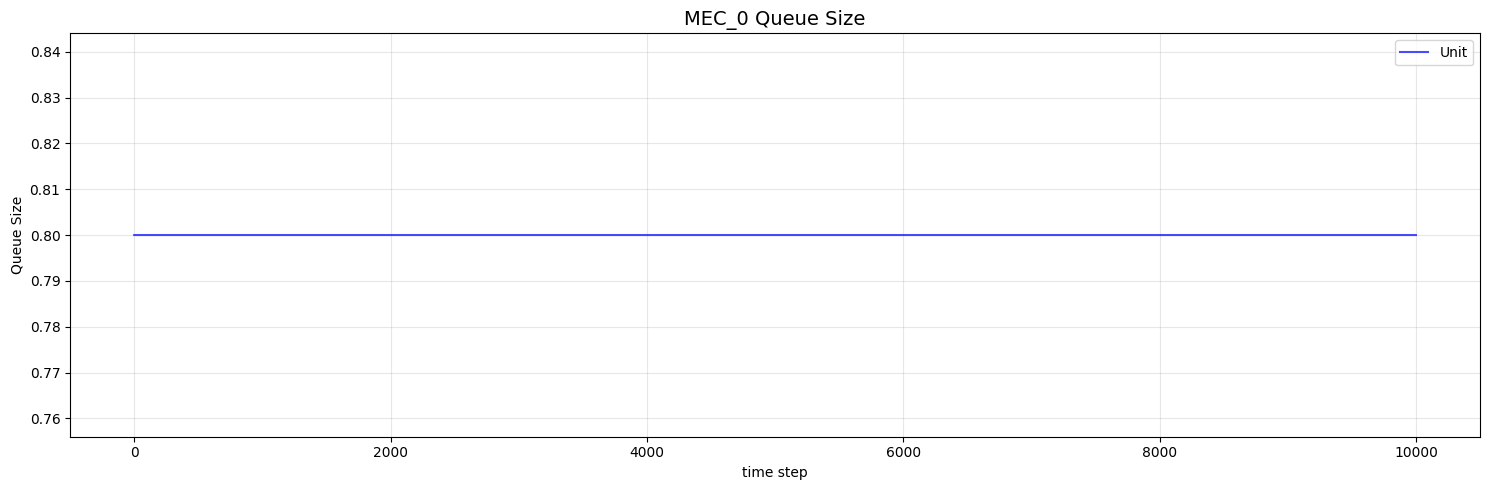

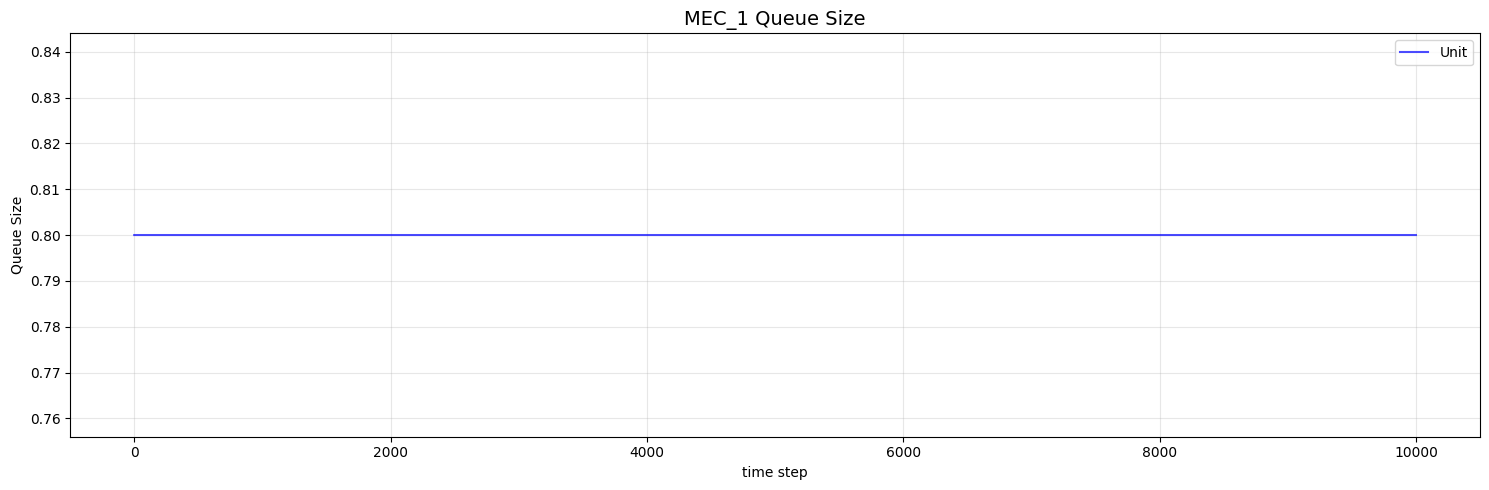

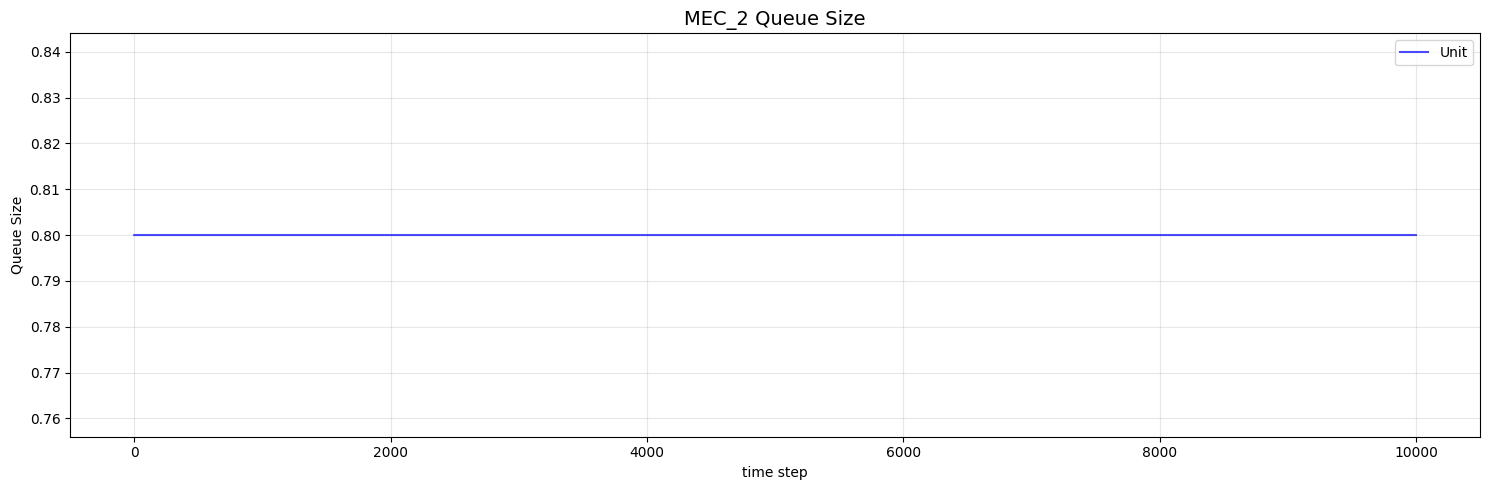

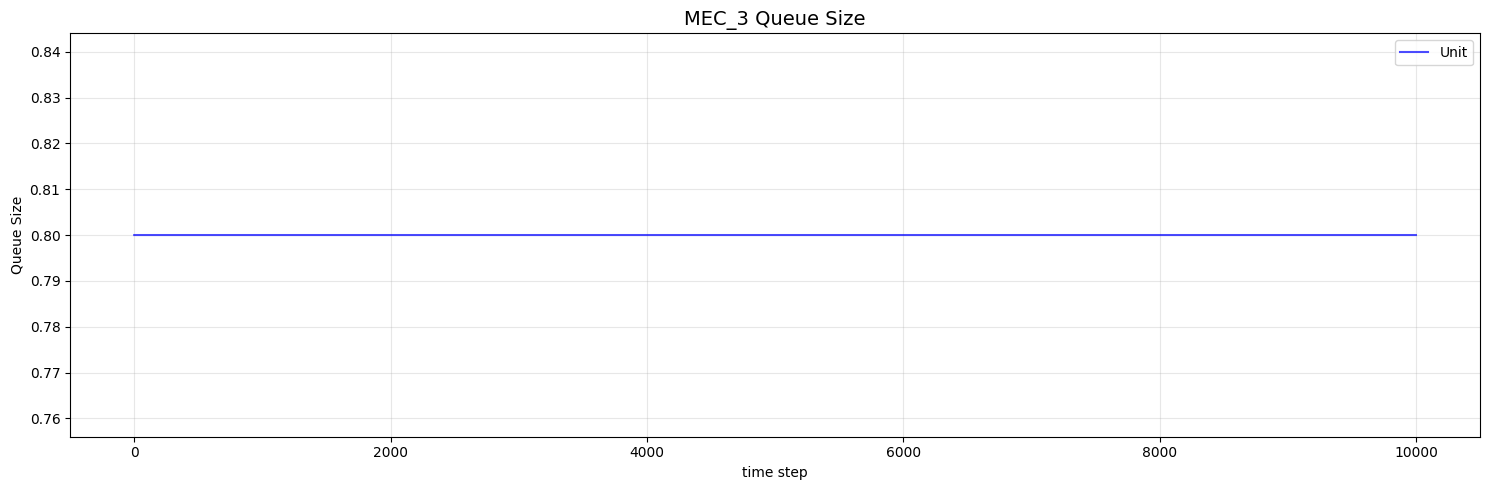

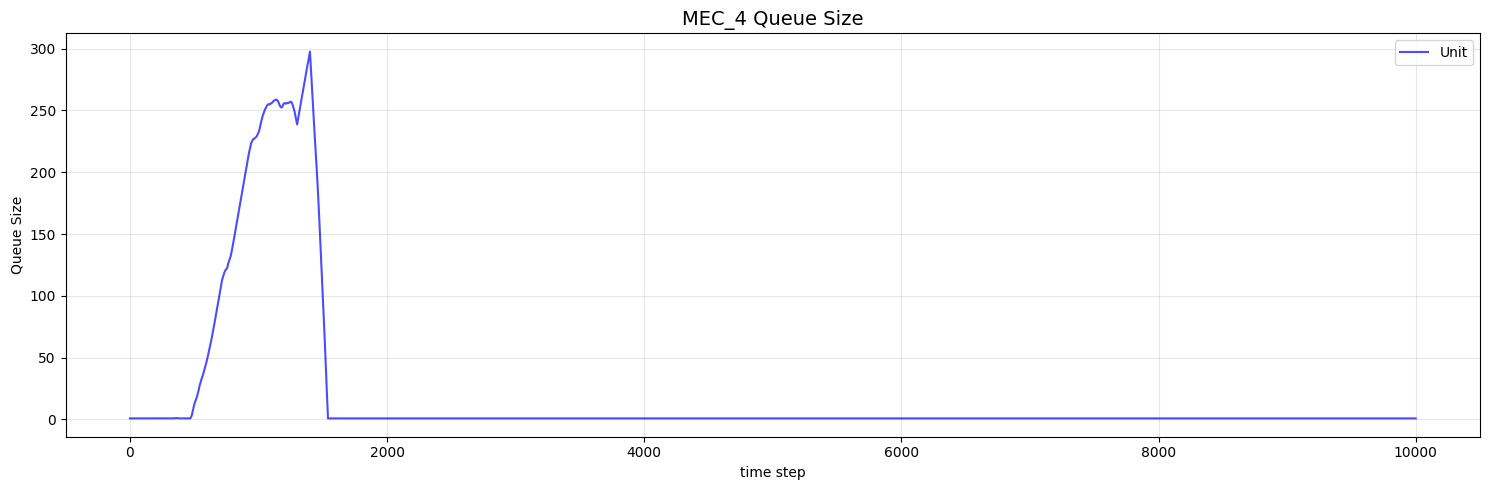

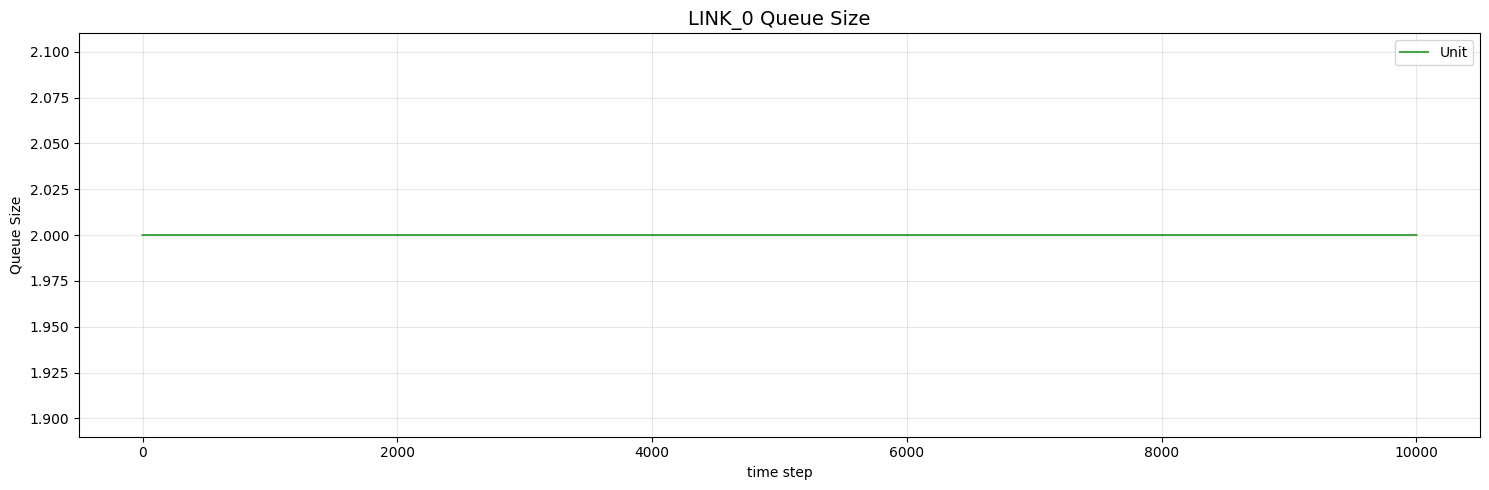

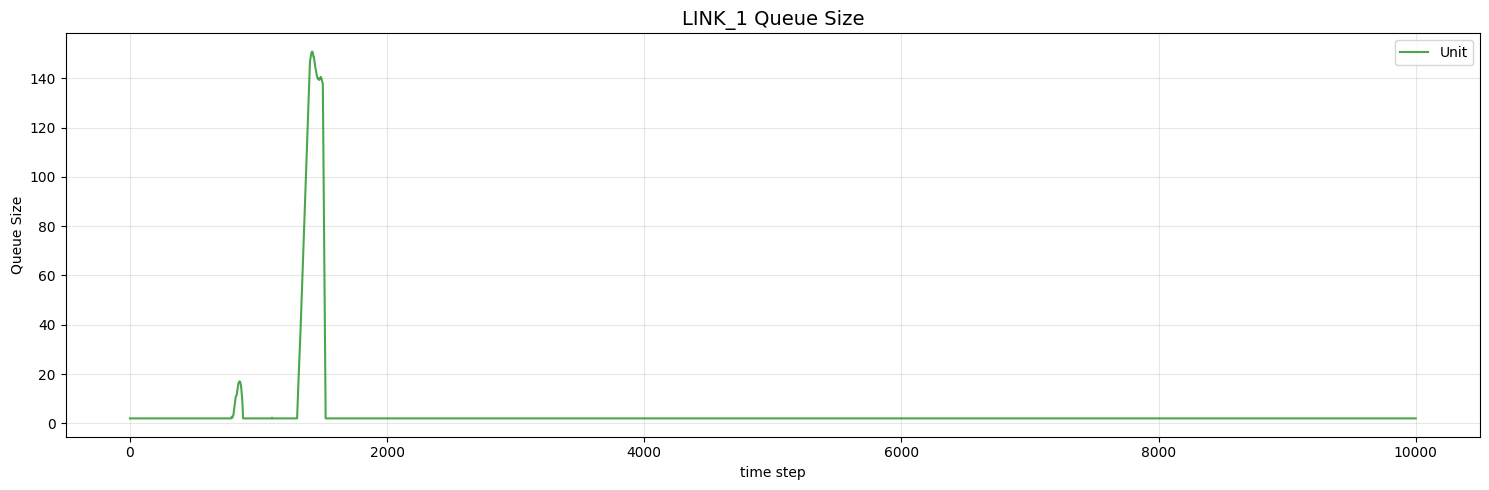

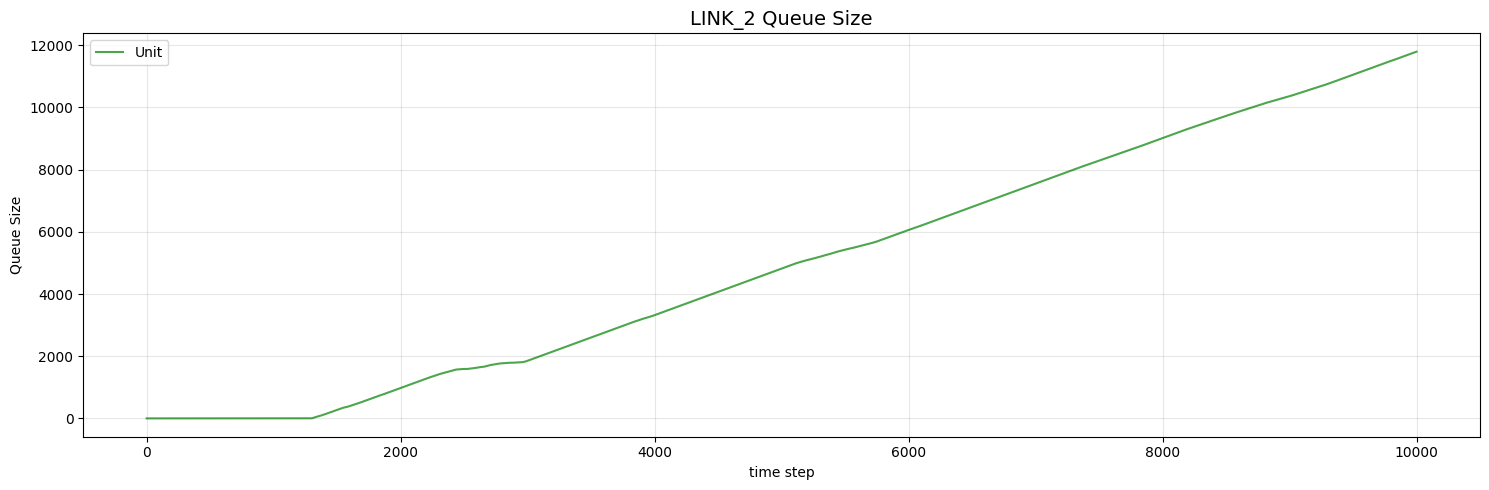

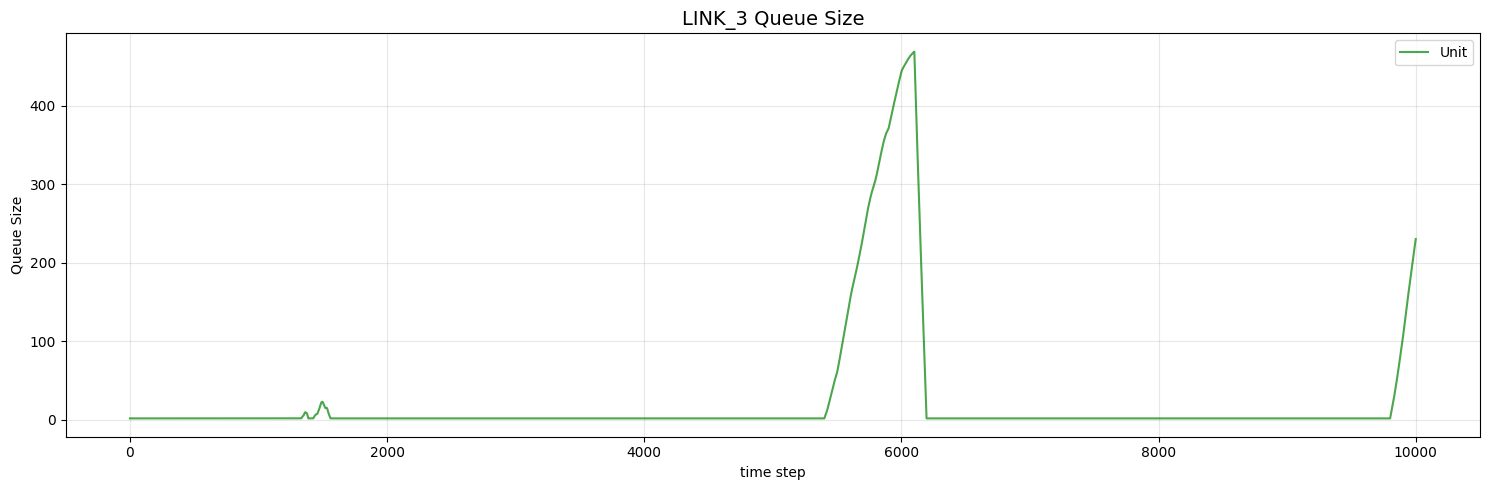

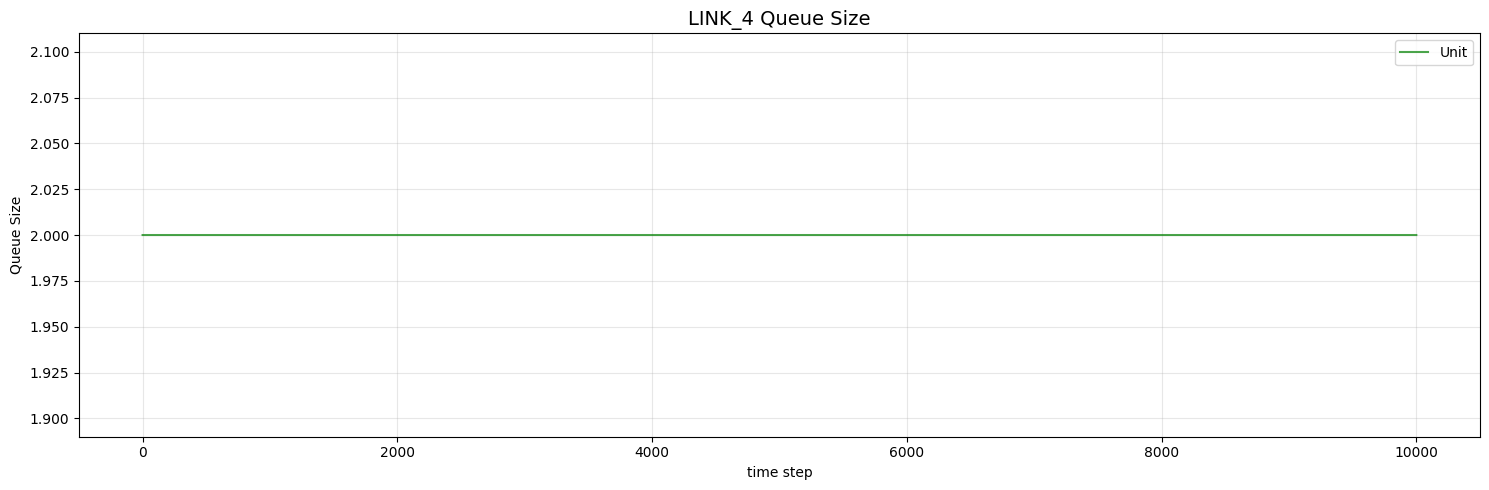

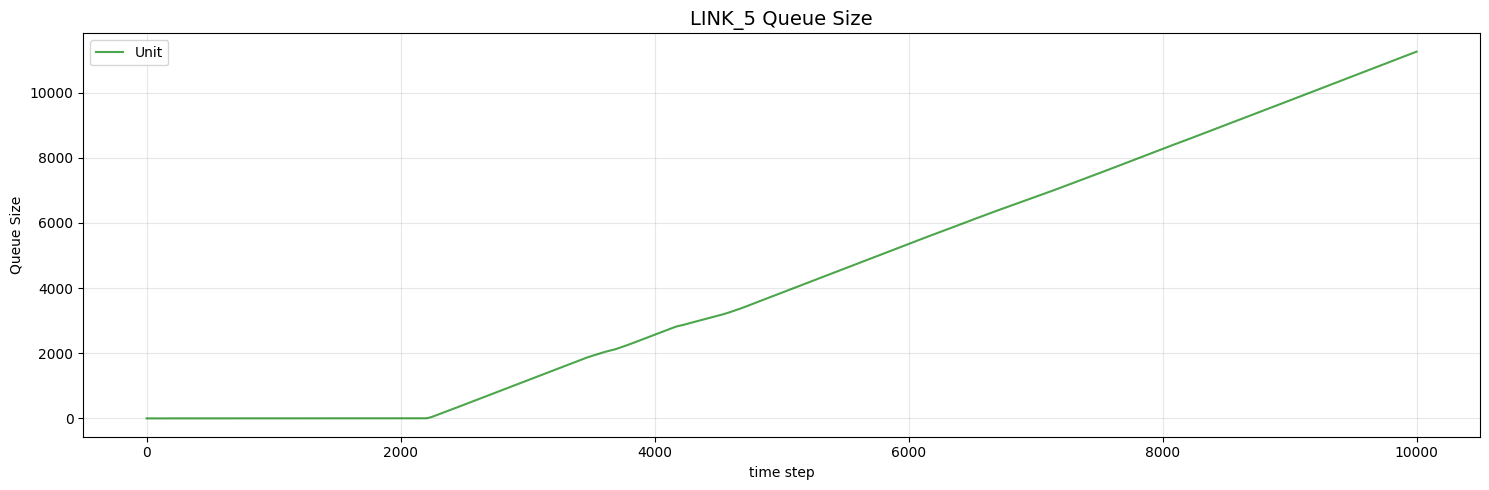

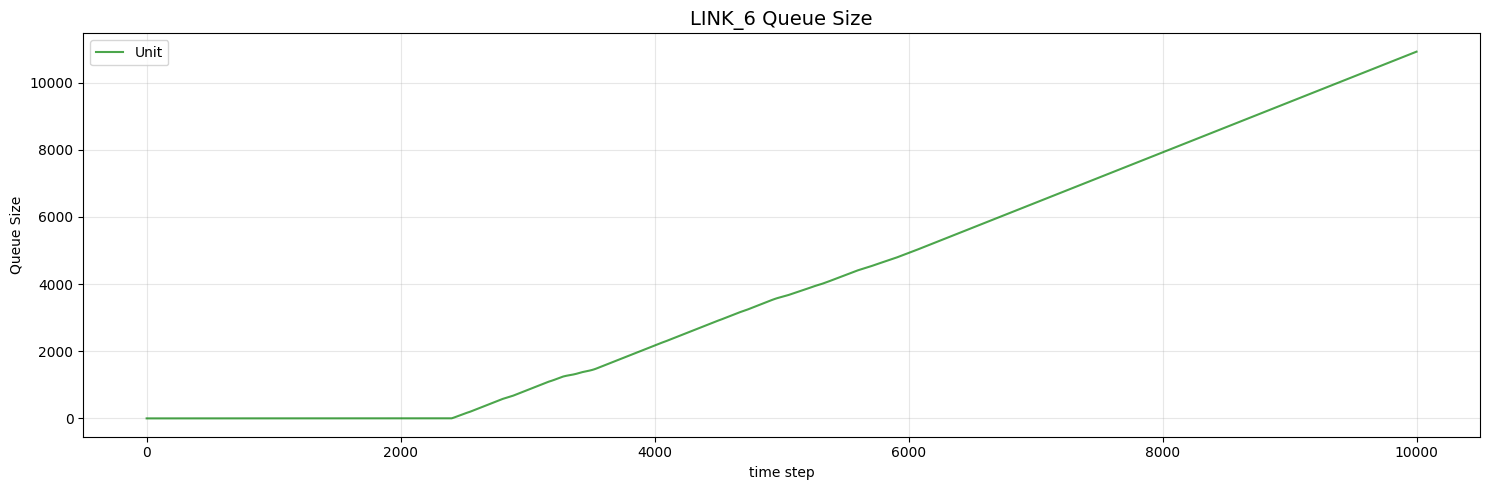

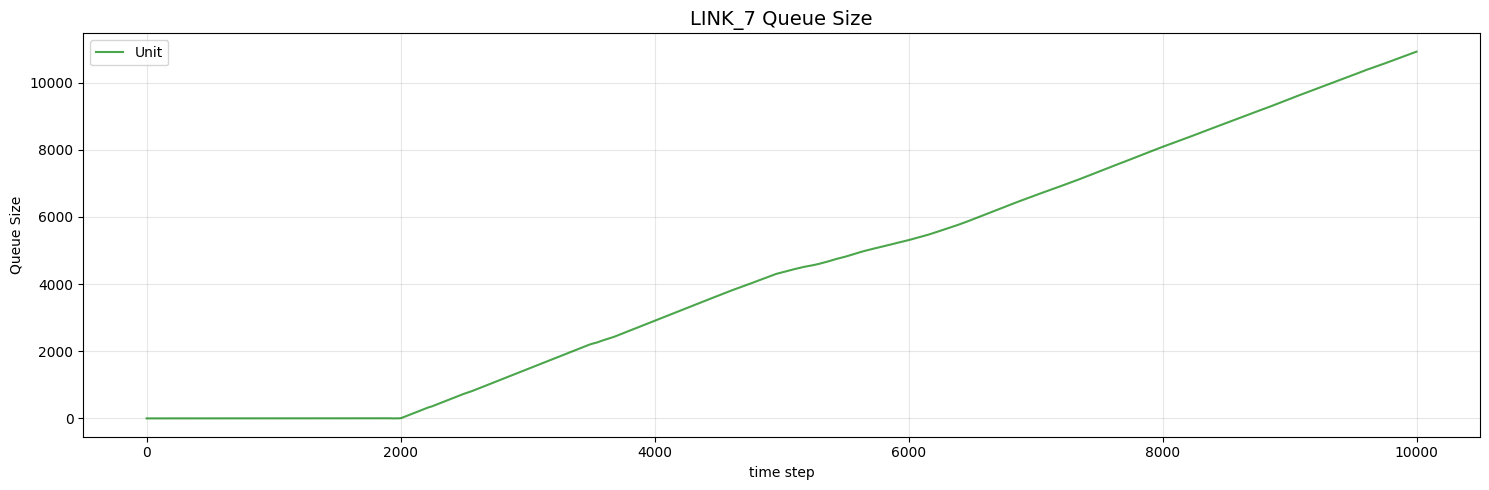

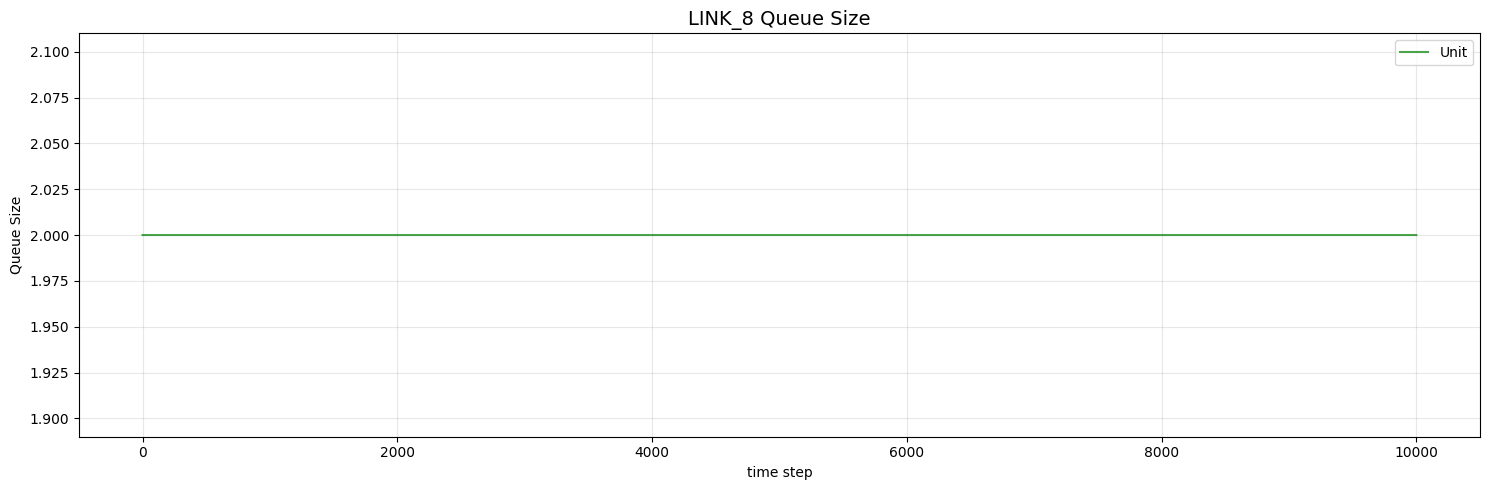

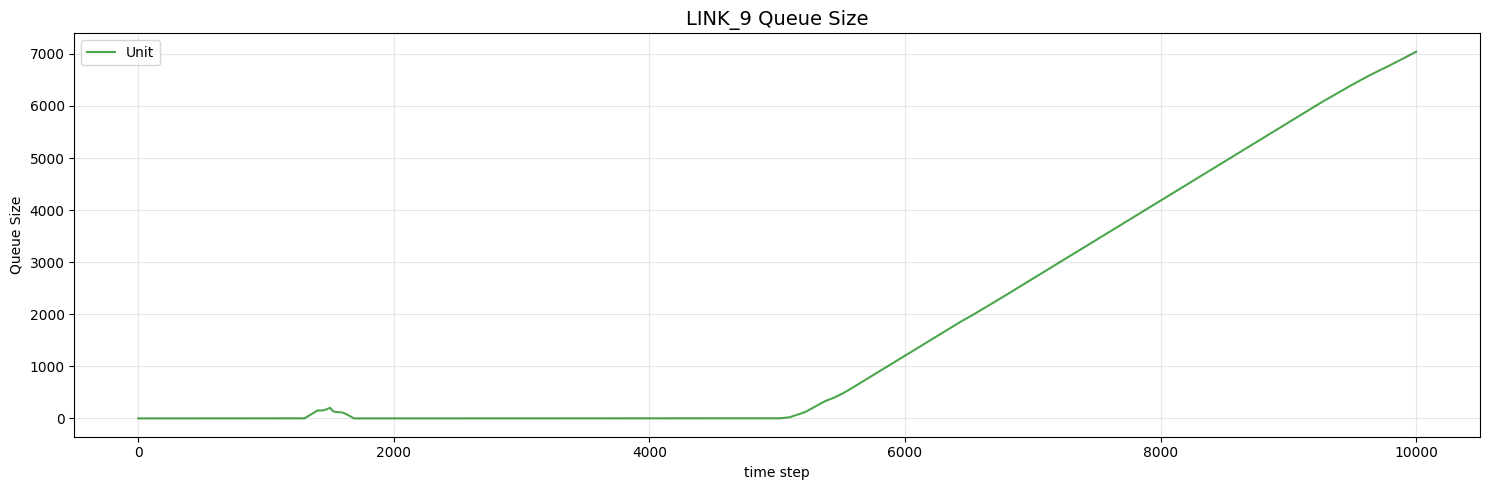

In [8]:
# Cell 4: Individual plots for each MEC and Link resource
sample_size = min(500000, len(action_df))  # Show more episodes for better trend visibility

# Plot MEC resources
mec_cols = [col for col in accumulated_df.columns if col.startswith('mec_')]
for i, mec in enumerate(mec_cols):
    fig, ax1= plt.subplots(1, 1, figsize=(15, 5))

    # Actions
    ax1.plot(accumulated_df.index[:sample_size], accumulated_df[mec][:sample_size], alpha=0.7, color='blue', label='Unit')
    ax1.set_title(f'{mec.upper()} Queue Size', fontsize=14)
    ax1.set_xlabel('time step')
    ax1.set_ylabel('Queue Size')
    ax1.grid(True, alpha=0.3)
    ax1.legend()


    plt.tight_layout()
    plt.show()

# Plot Link resources
link_cols = [col for col in accumulated_df.columns if col.startswith('link_')]
for i, link in enumerate(link_cols):
    fig, ax1 = plt.subplots(1, 1, figsize=(15, 5))

    # Actions
    ax1.plot(accumulated_df.index[:sample_size], accumulated_df[link][:sample_size], alpha=0.7, color='green', label='Unit')
    ax1.set_title(f'{link.upper()} Queue Size', fontsize=14)
    ax1.set_xlabel('time step')
    ax1.set_ylabel('Queue Size')
    ax1.grid(True, alpha=0.3)
    ax1.legend()


    plt.tight_layout()
    plt.show()

In [9]:
reward_df

,reward
0,0.565495
1,0.565268
2,0.565469
3,0.566067
4,0.566570
...,...
4100,0.113358
4101,0.113385
4102,0.113677
4103,0.113823


In [10]:
action_df['link_2']

0       0.384758
1       0.439337
2       0.432252
3       0.427198
4       0.436152
          ...   
9995    0.054649
9996    0.055884
9997    0.055547
9998    0.055661
9999    0.055997
Name: link_2, Length: 10000, dtype: float64

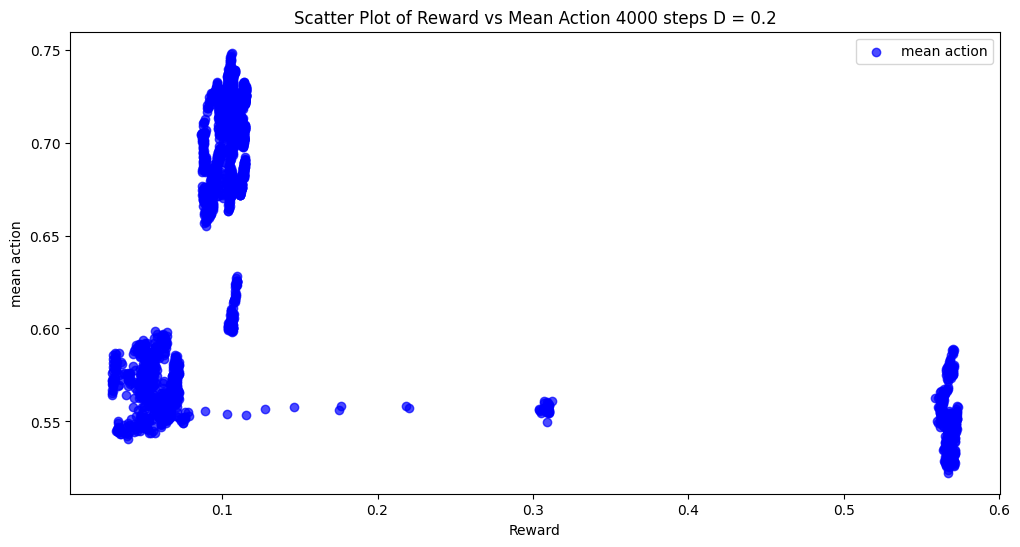

In [11]:
plt.figure(figsize=(12, 6))

mean_action = action_df.mean(axis=1)



plt.scatter(reward_df[:4000], mean_action[:4000], alpha=0.7, color='blue', label='mean action')
plt.xlabel('Reward')
plt.ylabel('mean action')
plt.title('Scatter Plot of Reward vs Mean Action 4000 steps D = 0.2')
plt.legend()
plt.show()

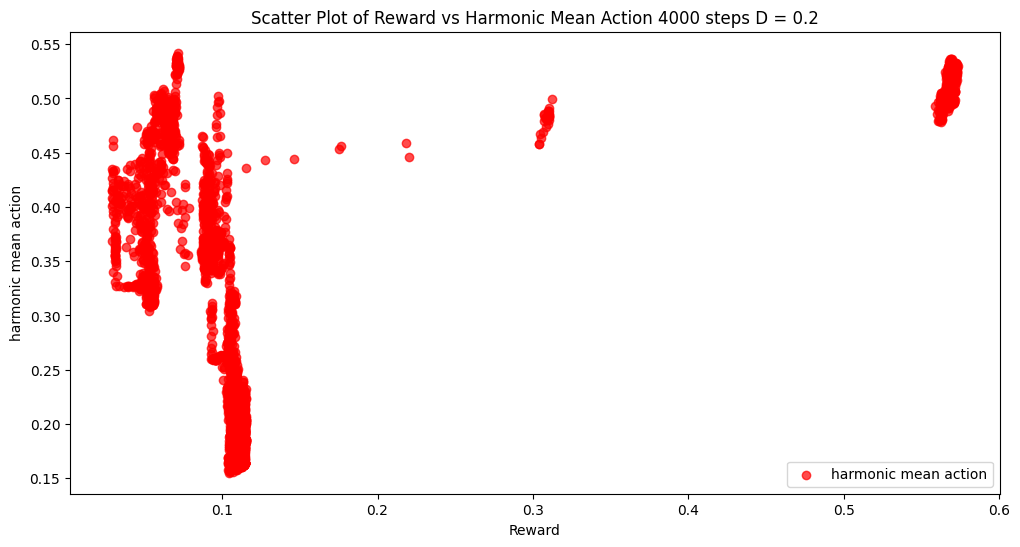

In [18]:
plt.figure(figsize=(12, 6))

harmonic_mean_action = action_df.apply(lambda row: len(row) / (1 / row).sum(), axis=1)


plt.scatter(reward_df[:4000], harmonic_mean_action[:4000], alpha=0.7, color='red', label='harmonic mean action')
plt.xlabel('Reward')
plt.ylabel('harmonic mean action')
plt.title('Scatter Plot of Reward vs Harmonic Mean Action 4000 steps D = 0.2')
plt.legend()
plt.show()

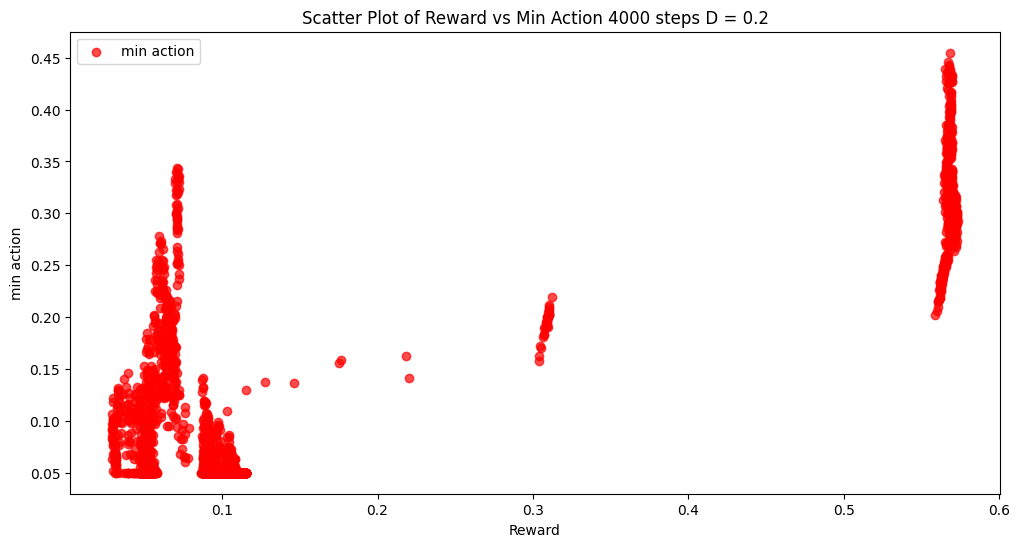

In [19]:
plt.figure(figsize=(12, 6))

min_action = action_df.min(axis=1)


plt.scatter(reward_df[:4000], min_action[:4000], alpha=0.7, color='red', label='min action')
plt.xlabel('Reward')
plt.ylabel('min action')
plt.title('Scatter Plot of Reward vs Min Action 4000 steps D = 0.2')
plt.legend()
plt.show()

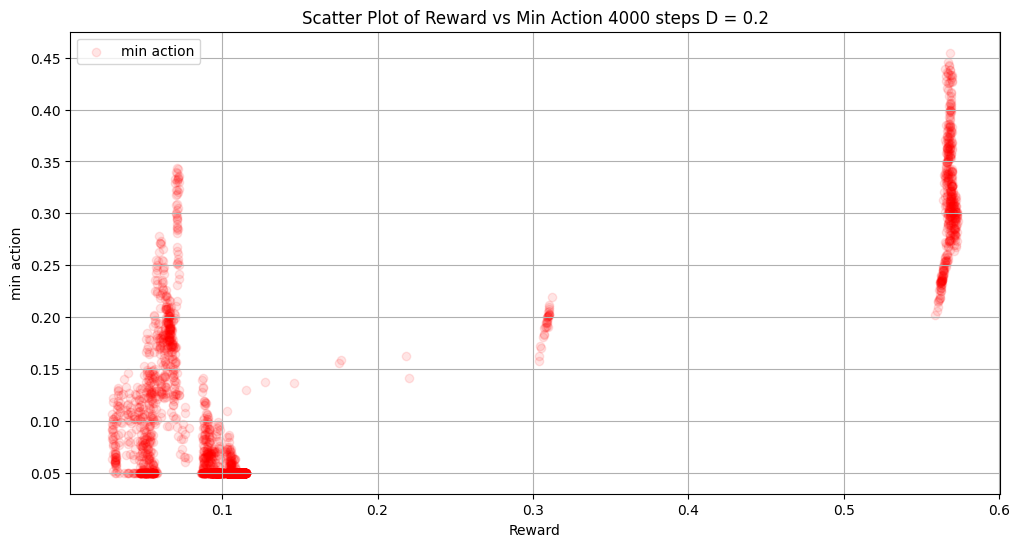

In [21]:
plt.figure(figsize=(12, 6))

min_action = action_df.min(axis=1)

plt.scatter(reward_df[:4000], min_action[:4000], alpha=0.1, color='red', label='min action')

plt.xlabel('Reward')
plt.ylabel('min action')
plt.title('Scatter Plot of Reward vs Min Action 4000 steps D = 0.2')

plt.legend()
plt.grid(True)   # ← Add grid here

plt.show()


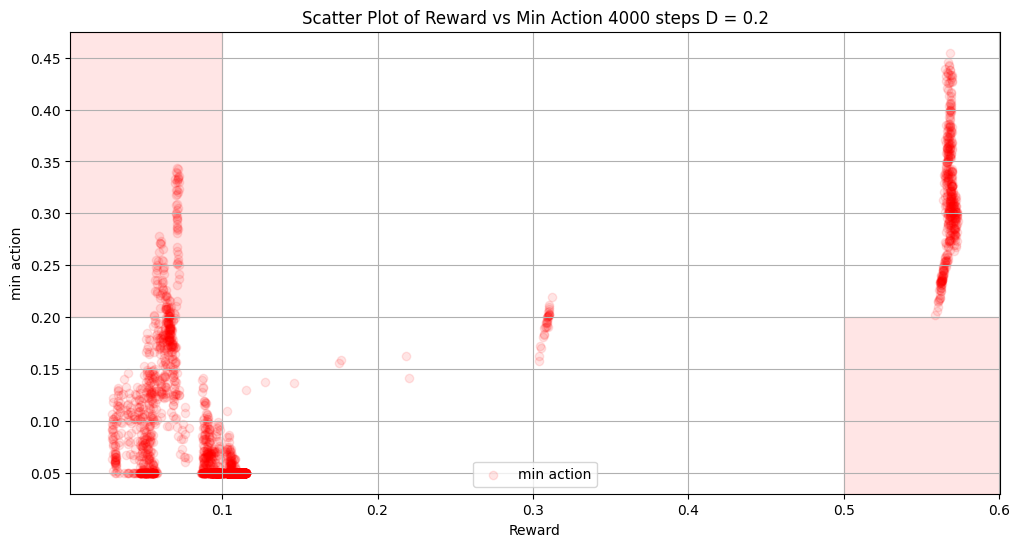

In [23]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.figure(figsize=(12, 6))

min_action = action_df.min(axis=1)

# Scatter
plt.scatter(reward_df[:4000], min_action[:4000],
            alpha=0.1, color='red', label='min action')

plt.xlabel('Reward')
plt.ylabel('min action')
plt.title('Scatter Plot of Reward vs Min Action 4000 steps D = 0.2')

plt.legend()
plt.grid(True)

ax = plt.gca()

# Make sure limits are set based on data before shading
plt.draw()
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# --- Bad region 1: x < 0.1 and y > 0.2 ---
width1 = 0.1 - x_min
height1 = y_max - 0.2
rect1 = Rectangle((x_min, 0.2), width1, height1,
                  color='red', alpha=0.1)
ax.add_patch(rect1)

# --- Bad region 2: x > 0.5 and y < 0.2 ---
width2 = x_max - 0.5
height2 = 0.2 - y_min
rect2 = Rectangle((0.5, y_min), width2, height2,
                  color='red', alpha=0.1)
ax.add_patch(rect2)

plt.show()


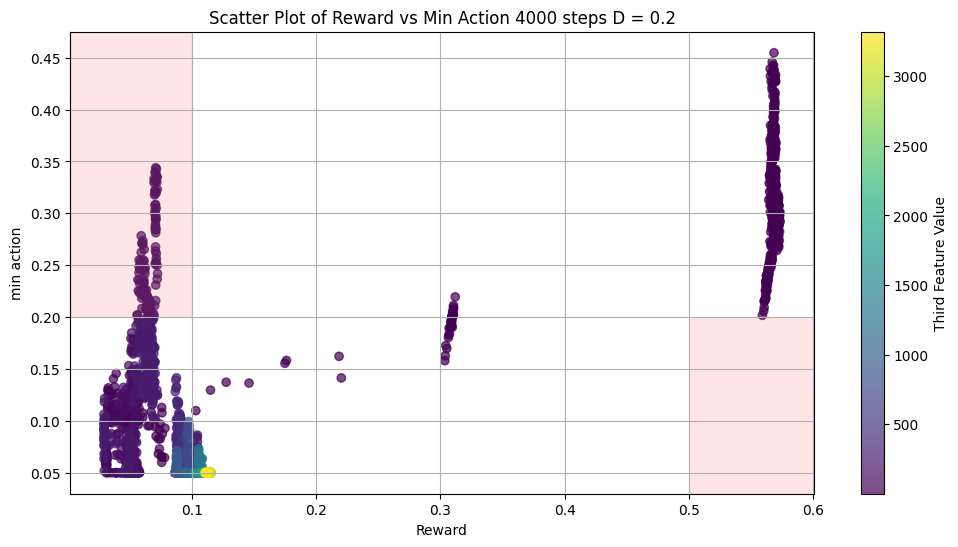

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.figure(figsize=(12, 6))

min_action = action_df.min(axis=1)
third_feature = accumulated_df.max(axis=1)[:4000]   # ← your third feature here

# Scatter with color scale
sc = plt.scatter(
    reward_df[:4000],
    min_action[:4000],
    c=third_feature,
    cmap='viridis',      # try 'plasma', 'inferno', 'coolwarm', etc.
    alpha=0.7
)

plt.xlabel('Reward')
plt.ylabel('min action')
plt.title('Scatter Plot of Reward vs Min Action 4000 steps D = 0.2')

plt.grid(True)

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('max queue size')

ax = plt.gca()

# Make sure limits are set before shading
plt.draw()
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# --- Bad region 1: x < 0.1 and y > 0.2 ---
rect1 = Rectangle(
    (x_min, 0.2),
    0.1 - x_min,
    y_max - 0.2,
    color='red',
    alpha=0.1
)
ax.add_patch(rect1)

# --- Bad region 2: x > 0.5 and y < 0.2 ---
rect2 = Rectangle(
    (0.5, y_min),
    x_max - 0.5,
    0.2 - y_min,
    color='red',
    alpha=0.1
)
ax.add_patch(rect2)

plt.show()
